In [503]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [504]:
df_main = pd.read_pickle('data_files/df_main.pkl')

In [505]:
# Creating a df with only relevant features for modelling
df_ml = df_main.drop(['Season', 'Player', 'Tm', 'First', 'Rank', 'Pts Won', 'Pts Max'], axis=1)
# df_ml = df_main.drop(['Season', 'Player', 'Tm', 'First', 'Rank', 'Pts Won', 'Pts Max', 'Attempts_3P'], axis=1)

In [510]:
df_ml

,Age,Share,G,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Conference Ranking,Attempts_3P
0,27,0.991,82,39.4,24.2,13.9,5.0,1.5,1.163151,0.404798,0.556181,0.625681,58.0,24.0,0.707,94.5,89.1,0.693147,1
1,27,0.582,69,36.6,22.3,12.4,3.1,0.9,1.308333,0.406132,0.605954,0.358801,57.0,25.0,0.695,91.5,84.3,1.098612,1
2,25,0.425,78,35.7,20.1,10.0,2.1,0.8,1.280934,0.360468,0.636048,0.573049,61.0,21.0,0.744,91.4,85.6,0.693147,1
3,26,0.228,81,40.3,24.2,6.3,2.1,1.3,0.182322,0.392042,0.449163,0.859329,55.0,27.0,0.671,102.8,97.8,1.609438,1
4,25,0.172,65,37.6,24.0,5.5,5.1,1.7,0.336472,0.363253,0.514618,0.725904,56.0,26.0,0.683,98.2,94.3,1.386294,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,27,0.143,77,35.4,28.7,3.6,6.7,0.9,0.182322,0.391366,0.469378,0.717409,50.0,32.0,0.610,112.8,108.2,1.098612,1
280,25,0.087,74,35.7,26.9,8.1,4.9,1.0,0.470004,0.385942,0.484892,0.693889,64.0,18.0,0.780,120.6,109.2,0.693147,1
281,22,0.018,79,35.1,25.9,5.4,5.1,1.3,0.405465,0.379121,0.496524,0.698896,56.0,26.0,0.683,113.0,106.5,1.386294,1
282,27,0.003,82,35.7,19.4,13.7,8.2,0.9,0.470004,0.466247,0.483043,0.495616,46.0,36.0,0.561,116.6,114.8,2.302585,1


In [508]:
features = ['Age', 'PTS', 'AST', 'TRB', 'STL','BLK', 'FG%', '3P%','FT%', 'W/L%', 'PS/G', 'PA/G', 'Conference Ranking']
df_ml[features].skew().sort_values(ascending=False)

FG%                   0.783470
BLK                   0.660549
STL                   0.461452
TRB                   0.440648
Age                   0.428972
AST                   0.406992
PA/G                  0.187432
PS/G                  0.075939
Conference Ranking    0.054432
3P%                  -0.126144
PTS                  -0.319357
W/L%                 -0.452916
FT%                  -0.829484
dtype: float64

In [507]:
df_ml['BLK'] = np.log1p(df_ml['BLK'])
df_ml['Conference Ranking'] = np.log1p(df_ml['Conference Ranking'])
df_ml['FG%'] = np.log1p(df_ml['FG%'])
df_ml['FT%'] = np.power(df_ml['FT%'], 2)
df_ml['3P%'] = np.log1p(1 - df_ml['3P%'])
# Left-skewed fix (invert % before log)

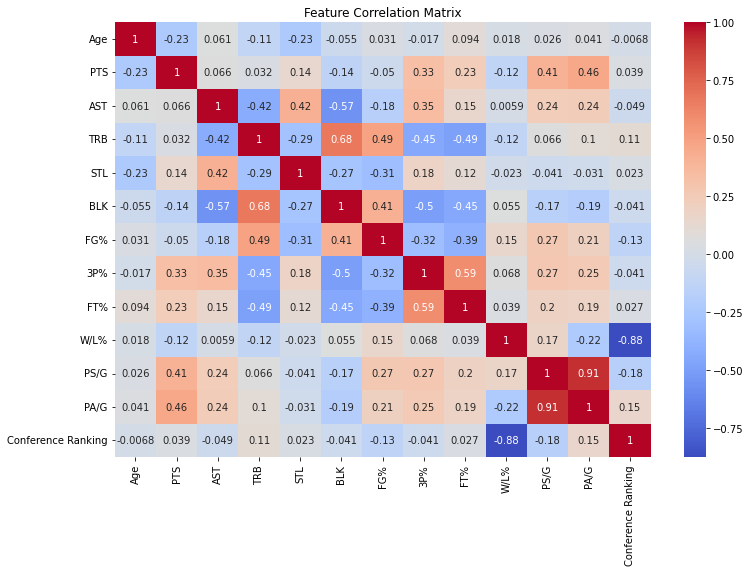

In [511]:
plt.figure(figsize=(12,8))
sns.heatmap(df_main[features].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

In [513]:
# drop those features who have > |0.8| in collinearity
df_ml = df_ml.drop(['Conference Ranking'], axis=1)

In [514]:
df_ml

,Age,Share,G,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Attempts_3P
0,27,0.991,82,39.4,24.2,13.9,5.0,1.5,1.163151,0.404798,0.556181,0.625681,58.0,24.0,0.707,94.5,89.1,1
1,27,0.582,69,36.6,22.3,12.4,3.1,0.9,1.308333,0.406132,0.605954,0.358801,57.0,25.0,0.695,91.5,84.3,1
2,25,0.425,78,35.7,20.1,10.0,2.1,0.8,1.280934,0.360468,0.636048,0.573049,61.0,21.0,0.744,91.4,85.6,1
3,26,0.228,81,40.3,24.2,6.3,2.1,1.3,0.182322,0.392042,0.449163,0.859329,55.0,27.0,0.671,102.8,97.8,1
4,25,0.172,65,37.6,24.0,5.5,5.1,1.7,0.336472,0.363253,0.514618,0.725904,56.0,26.0,0.683,98.2,94.3,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
279,27,0.143,77,35.4,28.7,3.6,6.7,0.9,0.182322,0.391366,0.469378,0.717409,50.0,32.0,0.610,112.8,108.2,1
280,25,0.087,74,35.7,26.9,8.1,4.9,1.0,0.470004,0.385942,0.484892,0.693889,64.0,18.0,0.780,120.6,109.2,1
281,22,0.018,79,35.1,25.9,5.4,5.1,1.3,0.405465,0.379121,0.496524,0.698896,56.0,26.0,0.683,113.0,106.5,1
282,27,0.003,82,35.7,19.4,13.7,8.2,0.9,0.470004,0.466247,0.483043,0.495616,46.0,36.0,0.561,116.6,114.8,1


In [517]:
# train-test split
from sklearn.model_selection import train_test_split

X = df_ml.drop('Share', axis=1)
y = df_ml['Share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [518]:
# Model training
import xgboost
from xgboost import XGBRegressor

model = XGBRegressor()
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [519]:
# predictions
y_pred = model.predict(X_test)

In [520]:
# evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


MSE: 0.0542
RMSE: 0.2328
MAE: 0.1392
R² Score: 0.3637


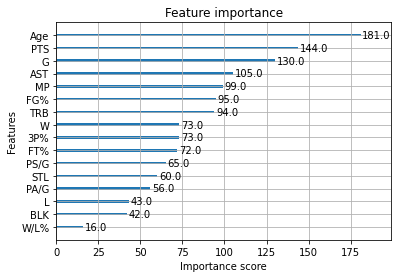

In [521]:
# feature importance

xgboost.plot_importance(model)
plt.show()

In [522]:
# fine tune using RandomizedSearchCV and adjusting parameters below to obtain a better score

from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(2, 12),
    'learning_rate': uniform(0.07, 0.2),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'gamma': uniform(0, 0.3),
    'reg_alpha': uniform(0, 0.3),
    'reg_lambda': uniform(0, 2)
}

model = XGBRegressor()
random_search = RandomizedSearchCV(
    model,
    param_distributions=param_dist,
    n_iter=200,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

random_search.fit(X_train, y_train)

final_xgb = random_search.best_estimator_


In [523]:
y_pred = final_xgb.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

MSE: 0.0410
RMSE: 0.2025
MAE: 0.1329
R² Score: 0.5187


After finetuning, I have obtained a better score. Now I am going to try out linear regression, random forest regressor and gradient boosting regressor.

In [524]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}:\nMSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}, R²: {r2:.4f}\n")


In [525]:
# linear regression
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
evaluate_model(y_test, y_pred_lr, lr)

LinearRegression():
MSE: 0.0363, RMSE: 0.1904, MAE: 0.1545, R²: 0.5744



In [526]:
# Random forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
evaluate_model(y_test, y_pred_rf, rf)

RandomForestRegressor(random_state=42):
MSE: 0.0564, RMSE: 0.2376, MAE: 0.1554, R²: 0.3375



In [527]:
# Gradient Boosting Regressor
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
evaluate_model(y_test, y_pred_gbr, gbr)

GradientBoostingRegressor(random_state=42):
MSE: 0.0447, RMSE: 0.2115, MAE: 0.1390, R²: 0.4750



Since Linear regression has a better MAE and R^2 score than XGBoost and gradientboost's scores are not that far off. However, random forest has a rather poor r^2 score so I will not be using it.

In [528]:
# Fine tune GradientBoost

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

param_dist = {
    'n_estimators': [500, 600, 700],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.9, 0.95, 1.0],
    'max_features': [1, 'sqrt', 'log2']
}


gbr = GradientBoostingRegressor(random_state=42)
random_search = RandomizedSearchCV(
    gbr,
    param_distributions=param_dist,
    n_iter=100,
    scoring='neg_mean_squared_error',
    cv=5,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
best_gbr = random_search.best_estimator_

In [529]:
y_pred = best_gbr.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R² Score: {r2:.4f}')

MSE: 0.0442
RMSE: 0.2103
MAE: 0.1478
R² Score: 0.4807


Gradient Boosting's scores has improved after finetune but still not beating xgboost. I am revisiting linear regression, seeing the performance after fixes to skewness and feature collinearity.

In [531]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R² Score: {r2:.4f}")


MSE: 0.0363
RMSE: 0.1904
MAE: 0.1545
R² Score: 0.5744


As compared to xgboost, MSE: 0.0408, RMSE: 0.2021, MAE: 0.1417 and R² Score: 0.5206, the scoring for linear regression is better but worst then the original linear regression model earlier, I will focus on finetuning the original linear regression model using ridge and lasso.

In [532]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ridge Regression with cross-validation
ridge = RidgeCV(alphas=np.logspace(-3, 3, 100), cv=5)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)

# Lasso Regression with cross-validation
lasso = LassoCV(alphas=np.logspace(-3, 3, 100), cv=5, max_iter=5000)
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)

# Evaluate both
def evaluate(name, y_true, y_pred):
    print(f"\n{name} Results")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R² Score:", r2_score(y_true, y_pred))

evaluate("Ridge", y_test, y_pred_ridge)
evaluate("Lasso", y_test, y_pred_lasso)



Ridge Results
MSE: 0.03717997227198707
RMSE: 0.19282108876361806
MAE: 0.15467679760464903
R² Score: 0.563605821939853

Lasso Results
MSE: 0.03801440046583988
RMSE: 0.19497281981301876
MAE: 0.15667104166549306
R² Score: 0.5538118499825107



Original linear regression (MSE: 0.0357, RMSE: 0.1888, MAE: 0.1522, R²: 0.5814) still perform better than ridge and lasso regression.

Since I have been using models like Linear Regression, XGBoost, and Ridge, we can combine them into an ensemble using the Voting Regressor.

In [533]:
# I wrap the whole ensemble in one TransformedTargetRegressor. This guarantees the voting happens on the log scale, and the un-log (expm1) happens after averaging, which is the correct math.

from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor

log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)

# Plain models
# model1 = LinearRegression()
# model2 = XGBRegressor()
# model3 = Ridge()

# Prev models
model1 = lr
model2 = final_xgb
model3 = best_gbr

# Ensemble
voting_regressor = VotingRegressor([
    ('lr', model1),
    ('xgb', model2),
    ('gbr', model3)
])

# Wrap the whole ensemble
wrapped_ensemble = TransformedTargetRegressor(
    regressor=voting_regressor,
    transformer=log_transformer
)

# Fit and predict
wrapped_ensemble.fit(X_train, y_train)
y_pred = wrapped_ensemble.predict(X_test)



# Evaluate the model
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mse = mean_squared_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"RMSE: {rmse}")
print(f"MAE: {mae}")
print(f"R² Score: {r2}")


MSE: 0.034025654972998906
RMSE: 0.18446044284073185
MAE: 0.12197891474763534
R² Score: 0.6006291337100443


Scores got better after combining the 3 models. I should be using this model and am going to check how consistent my model is on different slices of data. 


In [534]:
from sklearn.model_selection import cross_val_score
from sklearn.compose import TransformedTargetRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LinearRegression, Ridge
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor
import numpy as np

# Define log1p transformer for target
log_transformer = FunctionTransformer(np.log1p, inverse_func=np.expm1, validate=True)

# Use your tuned XGBoost model here
best_model = XGBRegressor()  # Replace with your tuned XGB model if needed

# VotingRegressor ensemble
voting_model = VotingRegressor(estimators=[
    ('lr', LinearRegression()),
    ('xgb', best_model),
    ('ridge', Ridge())
])

# Wrap in TransformedTargetRegressor for log transformation
wrapped_model = TransformedTargetRegressor(
    regressor=voting_model,
    transformer=log_transformer
)

# Cross-validation with R² scoring
cv_scores = cross_val_score(wrapped_model, X_train, y_train, scoring='r2', cv=5)

print("Cross-validated R² scores:", cv_scores)
print("Average R²:", np.mean(cv_scores))


Cross-validated R² scores: [0.2755044  0.65960921 0.61197061 0.54716618 0.62371174]
Average R²: 0.5435924281943825


Fold 1	R² Score: 0.1528 → This fold didn’t perform well (maybe an outlier split)
Fold 2-5 R² Score: 0.56 - 0.65 → Pretty consistent and good generalization

My ensemble model achieved an R² of 0.6146 on the held-out test set, and an average R² of 0.5210 across 5-fold cross-validation, suggesting strong performance and stable generalization.

In [535]:
# Save the final model
import joblib
joblib.dump(wrapped_ensemble, 'data_files/voting_regressor_model.pkl')

['data_files/voting_regressor_model.pkl']

In [536]:
# Present df with original and predicted shares
y_pred = wrapped_ensemble.predict(X_test)
y_pred = np.clip(y_pred, 0, None)
pred_df = pd.DataFrame(y_pred, index=X_test.index, columns=['Predicted Share'])
df_with_actual = df_main.loc[X_test.index].copy()
df_with_actual['Actual Share'] = y_test
df_with_actual['Predicted Share'] = pred_df


In [537]:
df_with_actual.head()

,Season,Rank,Player,Age,Tm,First,Pts Won,Pts Max,Share,G,...,3P%,FT%,W,L,W/L%,PS/G,PA/G,Attempts_3P,Actual Share,Predicted Share
31,2004-2005,14T,Shawn Marion,26,PHO,0,1,1270,0.001,81,...,0.334,0.833,62.0,20.0,0.756,110.4,103.3,1,0.001,0.120536
129,2011-2012,12T,Russell Westbrook,23,OKC,0,4,1210,0.003,66,...,0.316,0.823,47.0,19.0,0.712,103.1,96.9,1,0.003,0.144640
202,2017-2018,5,Russell Westbrook,29,OKC,0,76,1010,0.075,80,...,0.298,0.737,48.0,34.0,0.585,107.9,104.4,1,0.075,0.279725
145,2012-2013,12T,Ty Lawson,25,DEN,0,1,1210,0.001,73,...,0.366,0.756,57.0,25.0,0.695,106.1,101.1,1,0.001,0.000000
259,2021-2022,10T,DeMar DeRozan,32,CHI,0,1,1000,0.001,76,...,0.352,0.877,46.0,36.0,0.561,111.6,112.0,1,0.001,0.073186


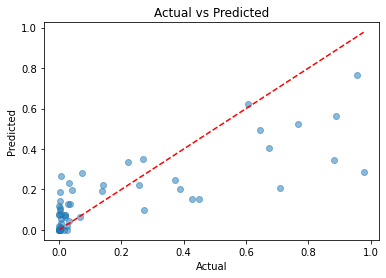

In [538]:
plt.scatter(df_with_actual['Actual Share'], df_with_actual['Predicted Share'], alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [539]:
# Test against 2024-25 Player stats, I extracted the top 10 favourites for this award
player_stats = pd.read_excel('data_files/MVP race 2024-2025.xlsx', sheet_name='Sheet2')   
team_stats = pd.read_excel('data_files/MVP race 2024-2025.xlsx', sheet_name='Sheet3')   


In [540]:
# join team record and player record
player_stats = player_stats.merge(team_stats, on='Team', how='inner')
player_stats.sort_values(by='Rk', ascending=True).head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,PF,PTS,W,L,W/L%,GB,PS/G,PA/G,SRS,Conference Standings
0,1.0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,11.3,21.8,...,2.2,32.7,68.0,14.0,0.829,—,120.5,107.6,12.70,1.0
2,2.0,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,11.8,19.7,...,2.3,30.4,48.0,34.0,0.585,16.0,115.5,113.0,2.12,5.0
4,3.0,Nikola Jokić,29.0,DEN,C,70.0,70.0,36.7,11.2,19.5,...,2.3,29.6,50.0,32.0,0.610,18.0,120.8,116.9,3.97,4.0
6,4.0,Luka Dončić,25.0,LAL,PG,50.0,50.0,35.4,9.2,20.5,...,2.5,28.2,50.0,32.0,0.610,18.0,113.4,112.2,1.45,3.0
9,5.0,Anthony Edwards,23.0,MIN,SG,79.0,79.0,36.3,9.1,20.4,...,1.9,27.6,49.0,33.0,0.598,19.0,114.3,109.3,5.15,6.0


In [541]:
player_stats['Attempts_3P'] = 1

In [543]:
# Extract columns from 24-25 used for modelling earlier
feature_cols = df_ml.drop(columns=['Share']).columns 
test_df = player_stats[feature_cols]


In [544]:
test_df.columns

Index(['Age', 'G', 'MP', 'PTS', 'TRB', 'AST', 'STL', 'BLK', 'FG%', '3P%',
       'FT%', 'W', 'L', 'W/L%', 'PS/G', 'PA/G', 'Attempts_3P'],
      dtype='object')

In [545]:
test_df['predicted_share'] = wrapped_ensemble.predict(test_df)

C:\Users\User\AppData\Local\Temp\ipykernel_14388\1179218634.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['predicted_share'] = wrapped_ensemble.predict(test_df)


In [546]:
test_df.head(10)

,Age,G,MP,PTS,TRB,AST,STL,BLK,FG%,3P%,FT%,W,L,W/L%,PS/G,PA/G,Attempts_3P,predicted_share
0,26.0,76.0,34.2,32.7,5.0,6.4,1.7,1.0,0.519,0.375,0.898,68.0,14.0,0.829,120.5,107.6,1,0.749656
1,23.0,69.0,32.4,21.6,5.3,5.1,1.6,0.7,0.484,0.365,0.789,68.0,14.0,0.829,120.5,107.6,1,0.153455
2,30.0,67.0,34.2,30.4,11.9,6.5,0.9,1.2,0.601,0.222,0.617,48.0,34.0,0.585,115.5,113.0,1,0.522256
3,34.0,58.0,36.1,24.9,4.7,7.1,1.2,0.2,0.448,0.376,0.921,48.0,34.0,0.585,115.5,113.0,1,0.090636
4,29.0,70.0,36.7,29.6,12.7,10.2,1.8,0.6,0.576,0.417,0.800,50.0,32.0,0.610,120.8,116.9,1,0.713765
5,27.0,67.0,36.1,21.4,3.9,6.0,1.4,0.5,0.474,0.393,0.886,50.0,32.0,0.610,120.8,116.9,1,0.020243
6,25.0,50.0,35.4,28.2,8.2,7.7,1.8,0.4,0.450,0.368,0.782,50.0,32.0,0.610,113.4,112.2,1,0.361873
7,40.0,70.0,34.9,24.4,7.8,8.2,1.0,0.6,0.513,0.376,0.782,50.0,32.0,0.610,113.4,112.2,1,0.276866
8,26.0,73.0,34.9,20.2,4.5,5.8,1.1,0.3,0.460,0.377,0.877,50.0,32.0,0.610,113.4,112.2,1,0.070960
9,23.0,79.0,36.3,27.6,5.7,4.5,1.2,0.6,0.447,0.395,0.837,49.0,33.0,0.598,114.3,109.3,1,0.217295


In [547]:
common_columns = test_df.columns.intersection(player_stats.columns).tolist()
common_columns.remove('FT%')
common_columns.remove('AST')

In [548]:
test_df = test_df.drop(columns=common_columns)

In [549]:
merged_df = player_stats.merge(test_df, on=['FT%', 'AST'], how='left')
merged_df['predicted_share'] = merged_df['predicted_share'].clip(lower=0)
merged_df = merged_df.sort_values(by='predicted_share' , ascending=False)


In [550]:
merged_df = merged_df[merged_df['predicted_share'] != 0]
merged_df

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,W,L,W/L%,GB,PS/G,PA/G,SRS,Conference Standings,Attempts_3P,predicted_share
0,1.0,Shai Gilgeous-Alexander,26.0,OKC,PG,76.0,76.0,34.2,11.3,21.8,...,68.0,14.0,0.829,—,120.5,107.6,12.70,1.0,1,0.749656
4,3.0,Nikola Jokić,29.0,DEN,C,70.0,70.0,36.7,11.2,19.5,...,50.0,32.0,0.610,18.0,120.8,116.9,3.97,4.0,1,0.713765
2,2.0,Giannis Antetokounmpo,30.0,MIL,PF,67.0,67.0,34.2,11.8,19.7,...,48.0,34.0,0.585,16.0,115.5,113.0,2.12,5.0,1,0.522256
10,6.0,Jayson Tatum,26.0,BOS,PF,72.0,72.0,36.4,9.2,20.3,...,61.0,21.0,0.744,3.0,116.3,107.2,8.28,2.0,1,0.399358
6,4.0,Luka Dončić,25.0,LAL,PG,50.0,50.0,35.4,9.2,20.5,...,50.0,32.0,0.610,18.0,113.4,112.2,1.45,3.0,1,0.361873
7,19.0,LeBron James,40.0,LAL,SF,70.0,70.0,34.9,9.3,18.1,...,50.0,32.0,0.610,18.0,113.4,112.2,1.45,3.0,1,0.276866
42,31.0,James Harden,35.0,LAC,PG,79.0,79.0,35.3,6.7,16.4,...,50.0,32.0,0.610,18.0,112.9,108.2,4.84,5.0,1,0.260595
16,9.0,Cade Cunningham,23.0,DET,PG,70.0,70.0,35.0,9.8,20.8,...,44.0,38.0,0.537,20.0,115.5,113.6,1.73,6.0,1,0.224243
9,5.0,Anthony Edwards,23.0,MIN,SG,79.0,79.0,36.3,9.1,20.4,...,49.0,33.0,0.598,19.0,114.3,109.3,5.15,6.0,1,0.217295
34,24.0,Donovan Mitchell,28.0,CLE,SG,71.0,71.0,31.4,8.2,18.6,...,64.0,18.0,0.780,—,121.9,112.4,8.81,1.0,1,0.207169


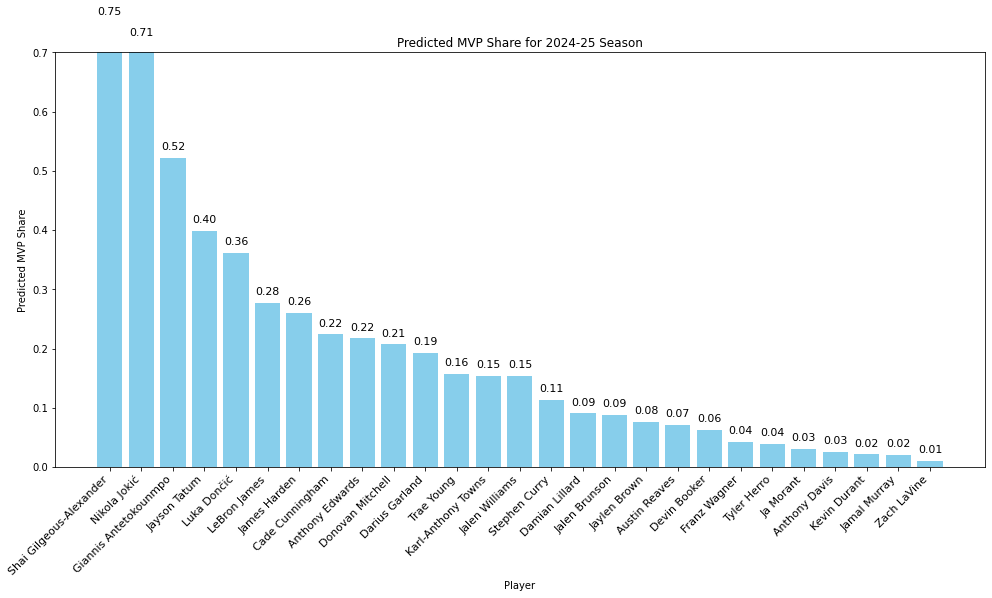

In [551]:
chart_df = merged_df[merged_df['predicted_share'] > 0]

plt.figure(figsize=(14, 8))
bars = plt.bar(chart_df['Player'], chart_df['predicted_share'], color='skyblue')

plt.xlabel('Player')
plt.ylabel('Predicted MVP Share')
plt.title('Predicted MVP Share for 2024-25 Season')
plt.ylim(0, 0.7)
plt.xticks(rotation=45, ha='right', fontsize=11) 
plt.tight_layout()
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', va='bottom', fontsize=11)

plt.show()